# Processed Data Quality Check and Visualisation

This notebook is used to check the processed data after running `processing_data.py`.

It checks the three processed files:

1. `traffic_timeseries.csv`
2. `scats_site_listing_clean.csv`
3. `traffic_count_locations_clean.csv`

Purpose:

- Confirm that processed files were created correctly.
- Check missing values, duplicates, and basic data quality.
- Visualise processed traffic flow and location data.
- Confirm whether the processed data is ready for model training / project use.

This notebook should be placed inside:

```text
cos30019_assignment2_b/data/processed/
```


## 1. Setup

In [23]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

BASE_DIR = Path.cwd()

traffic_file = BASE_DIR / "traffic_timeseries.csv"
site_listing_file = BASE_DIR / "scats_site_listing_clean.csv"
locations_file = BASE_DIR / "traffic_count_locations_clean.csv"

print("Current folder:", BASE_DIR)
print("Traffic processed file:", traffic_file)
print("Site listing processed file:", site_listing_file)
print("Locations processed file:", locations_file)

for file_path in [traffic_file, site_listing_file, locations_file]:
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")


Current folder: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/processed
Traffic processed file: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/processed/traffic_timeseries.csv
Site listing processed file: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/processed/scats_site_listing_clean.csv
Locations processed file: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/processed/traffic_count_locations_clean.csv


# 2. Processed Traffic Time-Series Data

File:

```text
traffic_timeseries.csv
```

This is the main processed file for model training. It should contain one row per `site_id` and `timestamp`.


In [50]:
traffic_ts = pd.read_csv(
    traffic_file,
    dtype={"site_id": str}
)

traffic_ts["site_id"] = traffic_ts["site_id"].str.zfill(4)
traffic_ts["timestamp"] = pd.to_datetime(traffic_ts["timestamp"])
traffic_ts["date_only"] = pd.to_datetime(traffic_ts["date_only"]).dt.date

print("Traffic time-series shape:", traffic_ts.shape)
display(traffic_ts.head())
display(traffic_ts.info())

Traffic time-series shape: (116160, 9)


,site_id,location,latitude,longitude,date_only,interval,timestamp,flow,is_valid_coordinate
0,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,0,2006-10-01 00:00:00,262,True
1,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,1,2006-10-01 00:15:00,248,True
2,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,2,2006-10-01 00:30:00,199,True
3,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,3,2006-10-01 00:45:00,176,True
4,0970,WARRIGAL_RD N of HIGH STREET_RD,-37.867303,145.091511,2006-10-01,4,2006-10-01 01:00:00,177,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116160 entries, 0 to 116159
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   site_id              116160 non-null  object        
 1   location             116160 non-null  object        
 2   latitude             116160 non-null  float64       
 3   longitude            116160 non-null  float64       
 4   date_only            116160 non-null  object        
 5   interval             116160 non-null  int64         
 6   timestamp            116160 non-null  datetime64[ns]
 7   flow                 116160 non-null  int64         
 8   is_valid_coordinate  116160 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 7.2+ MB


None

In [25]:
# Basic quality check for processed traffic time-series

print("Columns:")
print(traffic_ts.columns.tolist())

print("\nNumber of SCATS sites:", traffic_ts["site_id"].nunique())
print("Number of dates:", traffic_ts["date_only"].nunique())
print("Number of intervals per day:", traffic_ts["interval"].nunique())
print("Date range:", traffic_ts["date_only"].min(), "to", traffic_ts["date_only"].max())

print("\nMissing values:")
display(traffic_ts.isna().sum())

print("\nDuplicated site_id + timestamp records:")
duplicate_count = traffic_ts.duplicated(subset=["site_id", "timestamp"]).sum()
print(duplicate_count)

print("\nZero flow records:")
print((traffic_ts["flow"] == 0).sum())

print("\nFlow summary:")
display(traffic_ts["flow"].describe())


Columns:
['site_id', 'location', 'latitude', 'longitude', 'date_only', 'interval', 'timestamp', 'flow', 'is_valid_coordinate']

Number of SCATS sites: 40
Number of dates: 31
Number of intervals per day: 96
Date range: 2006-10-01 to 2006-10-31

Missing values:


site_id                0
location               0
latitude               0
longitude              0
date_only              0
interval               0
timestamp              0
flow                   0
is_valid_coordinate    0
dtype: int64


Duplicated site_id + timestamp records:
0

Zero flow records:
94

Flow summary:


count    116160.000000
mean        360.237595
std         277.162500
min           0.000000
25%         105.000000
50%         325.000000
75%         573.000000
max        1409.000000
Name: flow, dtype: float64

In [26]:
# Check expected row count

num_sites = traffic_ts["site_id"].nunique()
num_dates = traffic_ts["date_only"].nunique()
num_intervals = traffic_ts["interval"].nunique()

expected_rows = num_sites * num_dates * num_intervals
actual_rows = len(traffic_ts)

print("Expected complete rows:", expected_rows)
print("Actual rows:", actual_rows)
print("Difference:", expected_rows - actual_rows)

if expected_rows != actual_rows:
    print("Note: Some SCATS site-days may be incomplete in the raw data.")
else:
    print("The processed traffic time-series is complete.")


Expected complete rows: 119040
Actual rows: 116160
Difference: 2880
Note: Some SCATS site-days may be incomplete in the raw data.


In [27]:
# Check suspicious coordinates in processed traffic data

traffic_coords = (
    traffic_ts[["site_id", "location", "latitude", "longitude"]]
    .drop_duplicates("site_id")
    .sort_values("site_id")
)

suspicious_coords = traffic_coords[
    (traffic_coords["latitude"].isna()) |
    (traffic_coords["longitude"].isna()) |
    (traffic_coords["latitude"] == 0) |
    (traffic_coords["longitude"] == 0) |
    (~traffic_coords["longitude"].between(140, 150)) |
    (~traffic_coords["latitude"].between(-39.5, -33.5))
]

print("Total SCATS coordinate records:", len(traffic_coords))
print("Suspicious SCATS coordinate records:", len(suspicious_coords))
display(suspicious_coords)


Total SCATS coordinate records: 40
Suspicious SCATS coordinate records: 1


,site_id,location,latitude,longitude
89952,4266,AUBURN_RD N of BURWOOD_RD,-28.368973,108.782585


## 2.1 Processed Traffic Visualisation

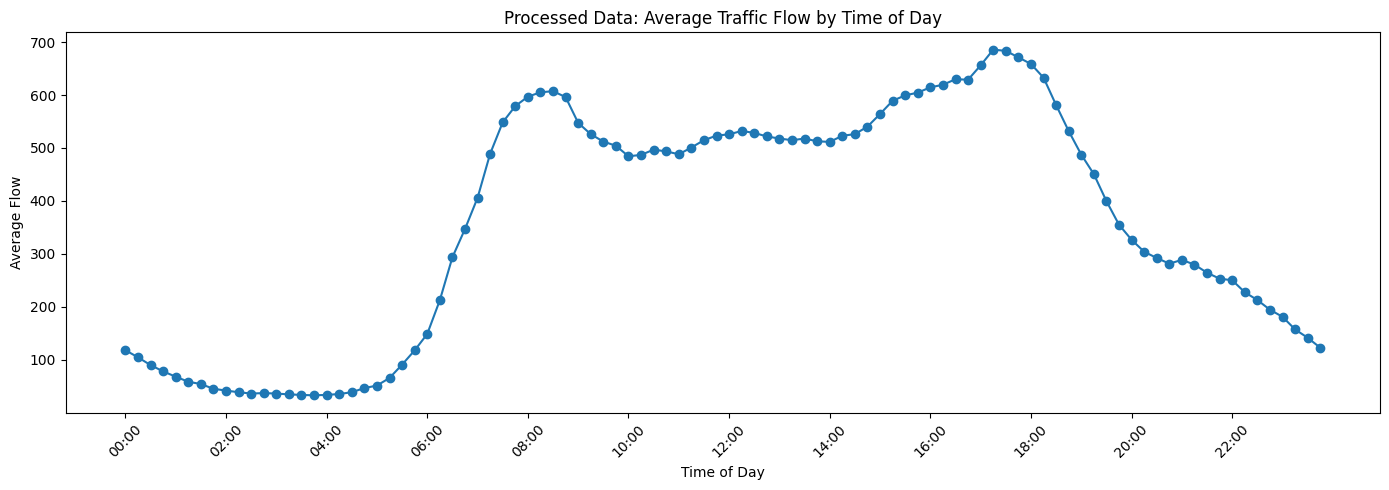

In [32]:
# Average traffic flow by time of day

avg_by_interval = traffic_ts.groupby("interval")["flow"].mean().reset_index()
avg_by_interval["time_label"] = (
    pd.to_datetime("2000-01-01")
    + pd.to_timedelta(avg_by_interval["interval"] * 15, unit="m")
).dt.strftime("%H:%M")

plt.figure(figsize=(14, 5))
plt.plot(avg_by_interval["interval"], avg_by_interval["flow"], marker="o")
plt.xticks(avg_by_interval["interval"][::8], avg_by_interval["time_label"][::8], rotation=45)
plt.title("Processed Data: Average Traffic Flow by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Flow")
plt.tight_layout()
plt.show()


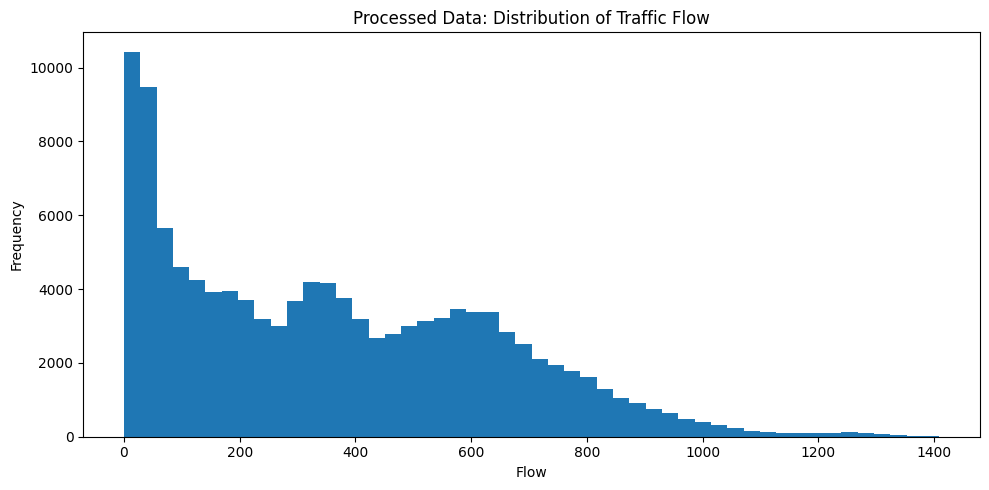

In [33]:
# Traffic flow distribution

plt.figure(figsize=(10, 5))
plt.hist(traffic_ts["flow"].dropna(), bins=50)
plt.title("Processed Data: Distribution of Traffic Flow")
plt.xlabel("Flow")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


,site_id,count,mean,min,max,std
1,2000,2784,616.851652,13,1409,408.201703
0,0970,2976,584.314516,0,1332,412.440780
24,4043,2976,536.963374,18,1151,330.529419
8,3002,2496,483.794872,0,1103,322.659499
5,2827,2976,483.756384,12,1295,330.442509
9,3120,2976,482.444556,93,974,245.467223
29,4263,2496,458.769231,16,1028,294.667730
21,4034,2976,454.466398,0,1028,290.663038
31,4266,2976,451.945901,0,1037,296.131477
14,3662,2976,442.295699,0,1057,288.734062


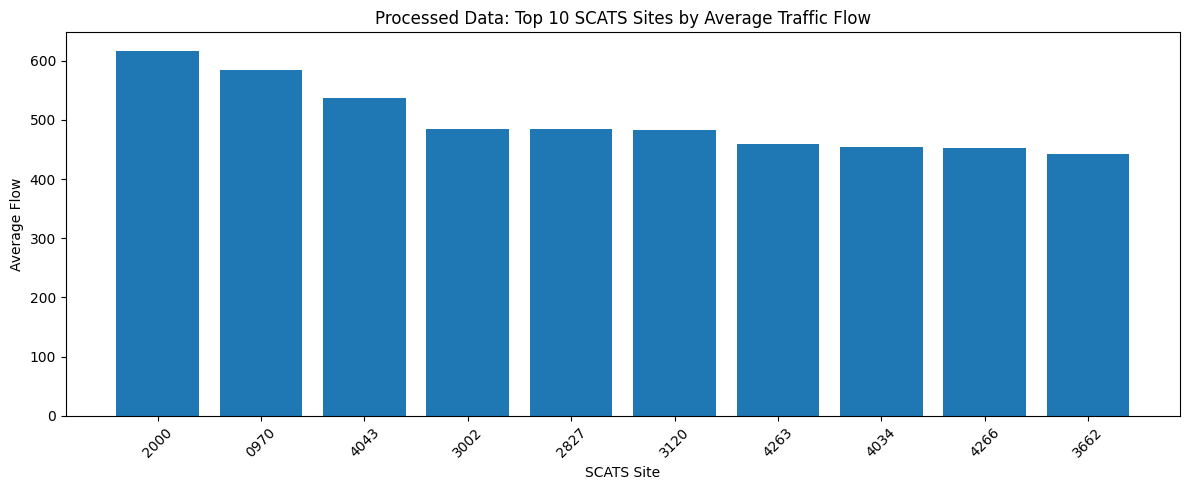

In [51]:
# Top 10 SCATS sites by average traffic flow

site_summary = (
    traffic_ts
    .groupby("site_id")["flow"]
    .agg(["count", "mean", "min", "max", "std"])
    .reset_index()
)

top_sites = site_summary.sort_values("mean", ascending=False).head(10)

display(top_sites)

plt.figure(figsize=(12, 5))
plt.bar(top_sites["site_id"].astype(str), top_sites["mean"])
plt.title("Processed Data: Top 10 SCATS Sites by Average Traffic Flow")
plt.xlabel("SCATS Site")
plt.ylabel("Average Flow")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

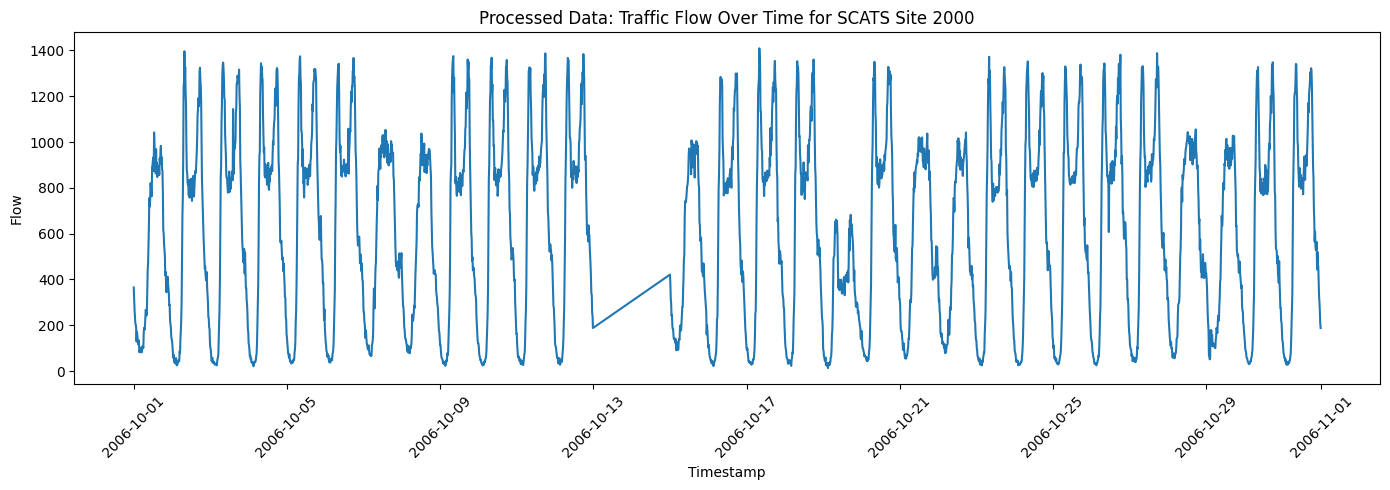

In [35]:
# Example time-series for busiest site

example_site = top_sites["site_id"].iloc[0]
example_data = traffic_ts[traffic_ts["site_id"] == example_site].sort_values("timestamp")

plt.figure(figsize=(14, 5))
plt.plot(example_data["timestamp"], example_data["flow"])
plt.title(f"Processed Data: Traffic Flow Over Time for SCATS Site {example_site}")
plt.xlabel("Timestamp")
plt.ylabel("Flow")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 3. Processed SCATS Site Listing Data

File:

```text
scats_site_listing_clean.csv
```

This file should contain clean SCATS site metadata for site lookup.


In [36]:
site_listing = pd.read_csv(site_listing_file)

site_listing["site_id"] = site_listing["site_id"].astype(str).str.zfill(4)

print("Site listing shape:", site_listing.shape)
display(site_listing.head())
display(site_listing.info())


Site listing shape: (4225, 6)


,site_id,site_number,location_description,site_type,directory,map_reference
0,0100,100,BURWOOD HWY NR LIVINGSTONE,INT,Melway,62G08
1,0101,101,WELLS/CHELSEA HEIGHTS HOTEL,INT,Melway,93F07
2,0102,102,MAROONDAH/NELSON/GOODALL,INT,Melway,38J03
3,0103,103,BURWOOD HWY NR REYNOLDS,POS,Melway,075F10
4,0104,104,MAROONDAH/GREEN,INT,Melway,278C01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   site_id               4225 non-null   object
 1   site_number           4225 non-null   int64 
 2   location_description  4225 non-null   object
 3   site_type             4225 non-null   object
 4   directory             4025 non-null   object
 5   map_reference         3896 non-null   object
dtypes: int64(1), object(5)
memory usage: 198.2+ KB


None

In [37]:
print("Columns:")
print(site_listing.columns.tolist())

print("\nUnique site IDs:", site_listing["site_id"].nunique())
print("Duplicated site IDs:", site_listing["site_id"].duplicated().sum())

print("\nMissing values:")
display(site_listing.isna().sum())

traffic_site_ids = set(traffic_ts["site_id"].astype(str).str.zfill(4).unique())
listing_site_ids = set(site_listing["site_id"].unique())

matched_sites = traffic_site_ids.intersection(listing_site_ids)
missing_from_listing = sorted(traffic_site_ids - listing_site_ids)

print("\nTraffic SCATS sites:", len(traffic_site_ids))
print("Matched in site listing:", len(matched_sites))
print("Missing from site listing:", missing_from_listing)


Columns:
['site_id', 'site_number', 'location_description', 'site_type', 'directory', 'map_reference']

Unique site IDs: 4225
Duplicated site IDs: 0

Missing values:


site_id                   0
site_number               0
location_description      0
site_type                 0
directory               200
map_reference           329
dtype: int64


Traffic SCATS sites: 40
Matched in site listing: 40
Missing from site listing: []


site_type
INT         2633
POS         1182
FLASH PX     189
O/H LANE     121
RAMP MTR      45
RBT MTR       19
FIRE W/W      18
FIRE SIG      12
AMBU SIG       3
BUS SIG        2
Name: count, dtype: int64

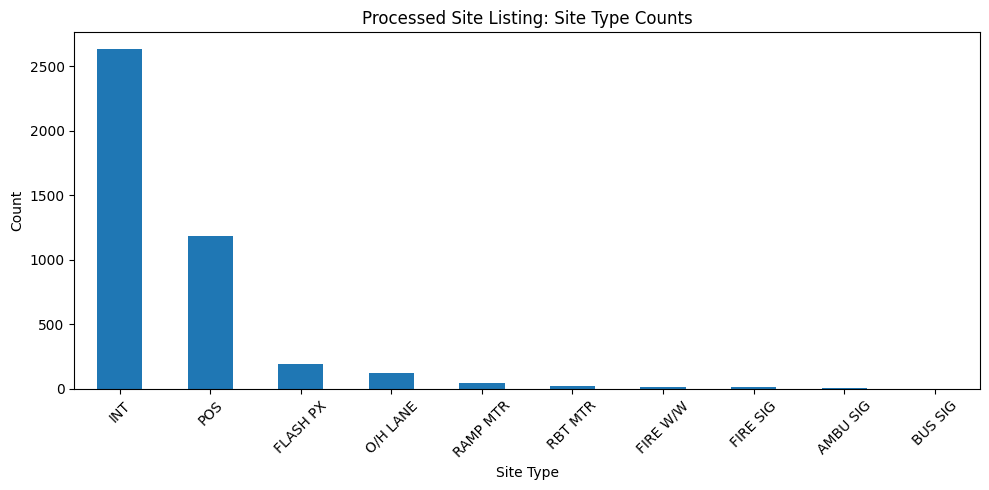

In [38]:
# Site type count visualisation

if "site_type" in site_listing.columns:
    site_type_counts = site_listing["site_type"].value_counts(dropna=False)
    display(site_type_counts.head(10))

    plt.figure(figsize=(10, 5))
    site_type_counts.head(10).plot(kind="bar")
    plt.title("Processed Site Listing: Site Type Counts")
    plt.xlabel("Site Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# 4. Processed Traffic Count Locations Data

File:

```text
traffic_count_locations_clean.csv
```

This file is supplementary location/reference metadata.


In [39]:
locations = pd.read_csv(locations_file)

if "tfm_id" in locations.columns:
    locations["tfm_id"] = locations["tfm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

print("Traffic count locations shape:", locations.shape)
display(locations.head())
display(locations.info())


Traffic count locations shape: (57947, 13)


,tfm_id,tfm_desc,site_desc,longitude,latitude,tfm_typ_de,movement_t,declared_r,local_road,aadt_all_vehicles,aadt_truck,percent_trucks,last_year
0,7656,CALDER HWY NE OF OAK ST,CALDER HWY & OAK ST,144.250614,-36.779313,INTERSECTION,All Moves,CALDER HIGHWAY,HIGH STREET,7700,330,0.04,1997
1,29406,MT DANDENONG RD S BD SE OF UPALONG RD,MT DANDENONG RD SE OF UPALONG RD,145.356779,-37.835309,INTERSECTION,All Moves,MOUNT DANDENONG ROAD,MOUNT DANDENONG TOURIST ROAD,1900,0,0.00,2000
2,22676,SWAN ST W BD E OF PUNT RD,PUNT RD LEFT TURN TO SWAN ST OD:12,144.988844,-37.824629,INTERSECTION,All Moves,HODDLE HIGHWAY,PUNT ROAD,15000,630,0.04,1993
3,27902,DYNON RD W BD E OF RADCLIFFE ST,DYNON RD & RADCLIFFE ST,144.932442,-37.803783,INTERSECTION,All Moves,DYNON ROAD,DYNON ROAD,12000,1300,0.10,1997
4,10935,DALTON RD N of CHILDS RD,CHILDS RD & DALTON RD,145.030601,-37.660502,INTERSECTION,All Moves,DALTON ROAD,DALTON ROAD,12000,600,0.05,1997


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57947 entries, 0 to 57946
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tfm_id             57947 non-null  object 
 1   tfm_desc           57947 non-null  object 
 2   site_desc          57947 non-null  object 
 3   longitude          57947 non-null  float64
 4   latitude           57947 non-null  float64
 5   tfm_typ_de         57947 non-null  object 
 6   movement_t         57947 non-null  object 
 7   declared_r         57947 non-null  object 
 8   local_road         57947 non-null  object 
 9   aadt_all_vehicles  57947 non-null  int64  
 10  aadt_truck         57947 non-null  int64  
 11  percent_trucks     57947 non-null  float64
 12  last_year          57947 non-null  int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 5.7+ MB


None

In [40]:
print("Columns:")
print(locations.columns.tolist())

for col in ["tfm_id", "longitude", "latitude"]:
    if col in locations.columns:
        print(f"{col}: missing =", locations[col].isna().sum())

if "tfm_id" in locations.columns:
    print("\nUnique TFM IDs:", locations["tfm_id"].nunique())
    print("Duplicated TFM IDs:", locations["tfm_id"].duplicated().sum())

if {"longitude", "latitude"}.issubset(locations.columns):
    print("\nCoordinate summary:")
    display(locations[["longitude", "latitude"]].describe())

if "aadt_all_vehicles" in locations.columns:
    print("\nAADT summary:")
    display(locations["aadt_all_vehicles"].describe())


Columns:
['tfm_id', 'tfm_desc', 'site_desc', 'longitude', 'latitude', 'tfm_typ_de', 'movement_t', 'declared_r', 'local_road', 'aadt_all_vehicles', 'aadt_truck', 'percent_trucks', 'last_year']
tfm_id: missing = 0
longitude: missing = 0
latitude: missing = 0

Unique TFM IDs: 57947
Duplicated TFM IDs: 0

Coordinate summary:


,longitude,latitude
count,57947.000000,57947.000000
mean,144.955527,-37.748906
std,0.824035,0.504714
min,140.963165,-38.937510
25%,144.879244,-37.954248
50%,145.025440,-37.821057
75%,145.176079,-37.731644
max,149.756130,-34.114537



AADT summary:


count     57947.000000
mean       4713.109393
std        9507.398130
min           0.000000
25%           0.000000
50%          80.000000
75%        6200.000000
max      123000.000000
Name: aadt_all_vehicles, dtype: float64

In [41]:
# Check direct matching between processed traffic site_id and processed location TFM_ID

if "tfm_id" in locations.columns:
    location_ids = set(locations["tfm_id"].dropna().unique())

    direct_matches = sorted(traffic_site_ids.intersection(location_ids))
    unmatched_sites = sorted(traffic_site_ids - location_ids)

    print("Traffic SCATS sites:", len(traffic_site_ids))
    print("Direct matches with TFM_ID:", len(direct_matches))
    print("Traffic SCATS sites not directly matched in TFM_ID:", unmatched_sites)


Traffic SCATS sites: 40
Direct matches with TFM_ID: 36
Traffic SCATS sites not directly matched in TFM_ID: ['0970', '2000', '2846', '3804']


## 4.1 Processed Location Visualisation

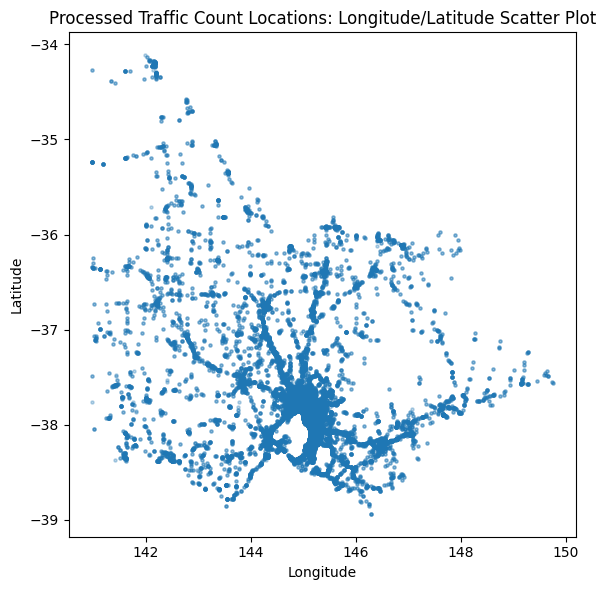

In [46]:
# Scatter plot of processed traffic count locations

if {"longitude", "latitude"}.issubset(locations.columns):
    plot_locations = locations.dropna(subset=["longitude", "latitude"])

    plt.figure(figsize=(6, 6))
    plt.scatter(plot_locations["longitude"], plot_locations["latitude"], s=5, alpha=0.3)
    plt.title("Processed Traffic Count Locations: Longitude/Latitude Scatter Plot")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()


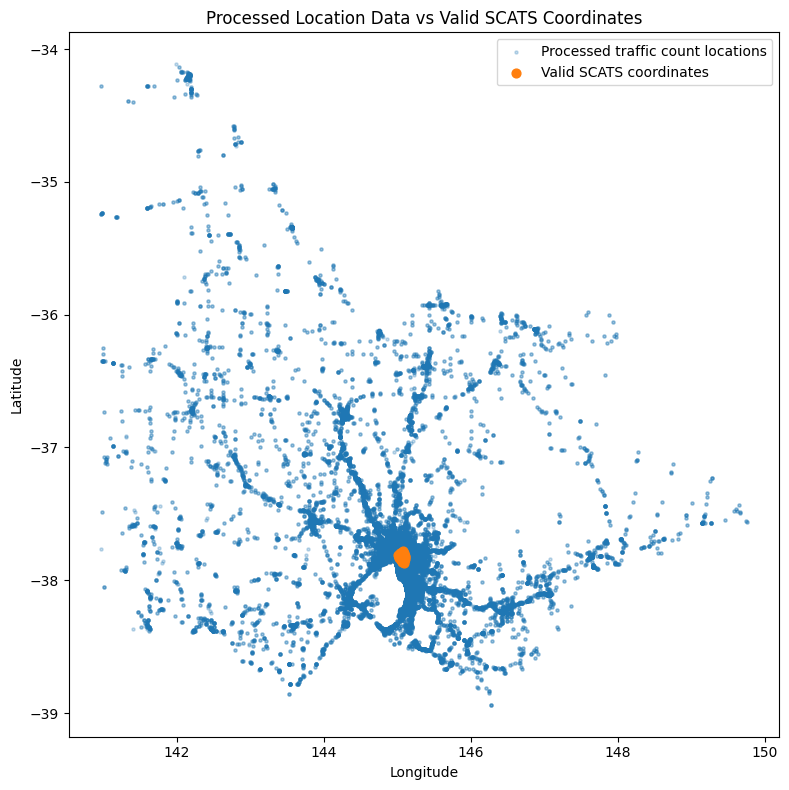

Invalid SCATS coordinates excluded from map:


,site_id,location,latitude,longitude
89952,4266,AUBURN_RD N of BURWOOD_RD,-28.368973,108.782585


In [49]:
# Plot processed location data with valid SCATS coordinates only

if {"longitude", "latitude"}.issubset(locations.columns):
    valid_traffic_coords = (
        traffic_ts[traffic_ts["is_valid_coordinate"] == True]
        [["site_id", "location", "latitude", "longitude"]]
        .drop_duplicates("site_id")
        .sort_values("site_id")
    )

    invalid_traffic_coords = (
        traffic_ts[traffic_ts["is_valid_coordinate"] == False]
        [["site_id", "location", "latitude", "longitude"]]
        .drop_duplicates("site_id")
        .sort_values("site_id")
    )

    plt.figure(figsize=(8, 8))

    plt.scatter(
        locations["longitude"],
        locations["latitude"],
        s=5,
        alpha=0.25,
        label="Processed traffic count locations"
    )

    plt.scatter(
        valid_traffic_coords["longitude"],
        valid_traffic_coords["latitude"],
        s=40,
        label="Valid SCATS coordinates"
    )

    plt.title("Processed Location Data vs Valid SCATS Coordinates")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Invalid SCATS coordinates excluded from map:")
    display(invalid_traffic_coords)

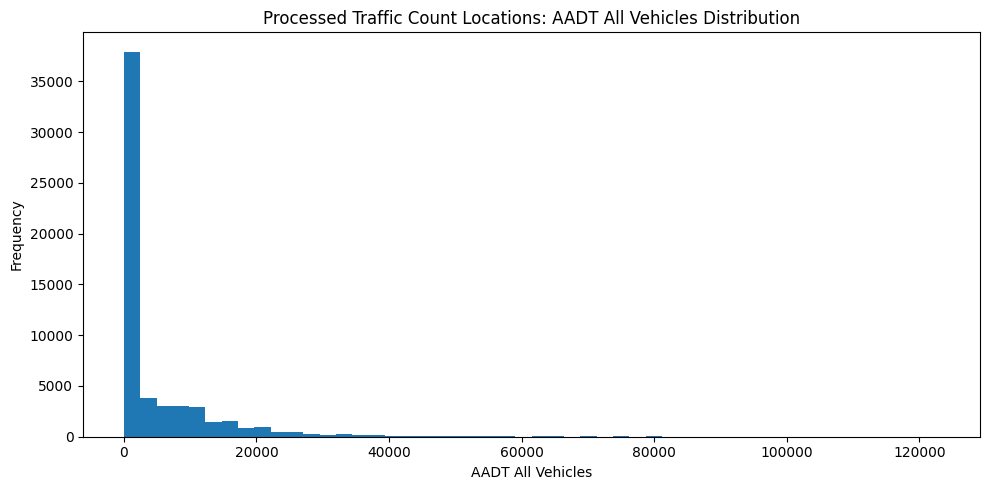

In [44]:
# AADT distribution

if "aadt_all_vehicles" in locations.columns:
    plt.figure(figsize=(10, 5))
    plt.hist(locations["aadt_all_vehicles"].dropna(), bins=50)
    plt.title("Processed Traffic Count Locations: AADT All Vehicles Distribution")
    plt.xlabel("AADT All Vehicles")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# 5. Final Quality Summary

Use this section to confirm whether the processed data is ready for the next stage.

Expected result:

- `traffic_timeseries.csv` should have no missing `flow`.
- `site_id + timestamp` should not be duplicated in `traffic_timeseries.csv`.
- `scats_site_listing_clean.csv` should include all 40 SCATS sites used in the traffic data.
- `traffic_count_locations_clean.csv` should be treated as supplementary data because `TFM_ID` does not fully match all SCATS sites.


In [22]:
print("FINAL CHECK SUMMARY")
print("=" * 60)

print("Traffic time-series:")
print("- Rows:", len(traffic_ts))
print("- Sites:", traffic_ts["site_id"].nunique())
print("- Missing flow:", traffic_ts["flow"].isna().sum())
print("- Duplicate site_id + timestamp:", traffic_ts.duplicated(subset=["site_id", "timestamp"]).sum())
print("- Suspicious coordinate records:", len(suspicious_coords))

print("\nSite listing:")
print("- Rows:", len(site_listing))
print("- Unique site IDs:", site_listing["site_id"].nunique())
print("- Missing traffic sites from listing:", missing_from_listing)

print("\nTraffic count locations:")
print("- Rows:", len(locations))
if "tfm_id" in locations.columns:
    print("- Unique TFM IDs:", locations["tfm_id"].nunique())
    print("- Direct matches with traffic SCATS sites:", len(direct_matches))
    print("- Unmatched traffic SCATS sites:", unmatched_sites)

print("\nConclusion:")
if traffic_ts["flow"].isna().sum() == 0 and traffic_ts.duplicated(subset=["site_id", "timestamp"]).sum() == 0 and len(missing_from_listing) == 0:
    print("Processed data quality looks acceptable for the next modelling stage.")
else:
    print("Some processed data issues need to be reviewed before modelling.")


FINAL CHECK SUMMARY
Traffic time-series:
- Rows: 116160
- Sites: 40
- Missing flow: 0
- Duplicate site_id + timestamp: 0
- Suspicious coordinate records: 1

Site listing:
- Rows: 4225
- Unique site IDs: 4225
- Missing traffic sites from listing: []

Traffic count locations:
- Rows: 57947
- Unique TFM IDs: 57947
- Direct matches with traffic SCATS sites: 36
- Unmatched traffic SCATS sites: ['0970', '2000', '2846', '3804']

Conclusion:
Processed data quality looks acceptable for the next modelling stage.
